In [4]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

cities = ['Mbeya', 'Dar', 'Arusha', 'Mwanza', 'Dodoma',]
print(f"Original cities list: {cities}")

Original cities list: ['Mbeya', 'Dar', 'Arusha', 'Mwanza', 'Dodoma']


In [ ]:

cities_reshaped = [[city] for city in cities]
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

one_hot_encoded_sklearn = encoder.fit_transform(cities_reshaped)

feature_names = encoder.get_feature_names_out(['city'])

one_hot_df_sklearn = pd.DataFrame(one_hot_encoded_sklearn, columns=feature_names)
display(one_hot_df_sklearn)

,city_Arusha,city_Dar,city_Dodoma,city_Mbeya,city_Mwanza
0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0


### Method 2: Using `pandas.get_dummies` (Non-Vectorizer Approach)

This method is straightforward for converting categorical columns in a DataFrame into dummy/indicator variables. It's often used for data preparation outside of a strict ML pipeline context, or when the entire dataset is available upfront.

In [6]:
# Convert the list to a Pandas Series or DataFrame
cities_series = pd.Series(cities, name='City')

# Apply get_dummies
one_hot_encoded_pandas = pd.get_dummies(cities_series, dtype=int)

display(one_hot_encoded_pandas)

,Arusha,Dar,Dodoma,Mbeya,Mwanza
0,0,0,0,1,0
1,0,1,0,0,0
2,1,0,0,0,0
3,0,0,0,0,1
4,0,0,1,0,0


### 1. Corpus Preparation

A **corpus** is a large and structured set of texts used for linguistic analysis. For this example, we'll create a small sample corpus.

In [14]:
sample_corpus = [
    "my name is baharia hamisi.",
    "am among of the AI and PROCESSING club.",
    "i like this club and i apprepiate this team"
]

print("Sample Corpus:")
for i, doc in enumerate(sample_corpus):
    print(f"Document {i+1}: {doc}")

Sample Corpus:
Document 1: my name is baharia hamisi.
Document 2: am among of the AI and PROCESSING club.
Document 3: i like this club and i apprepiate this team


### 2. Tokenization

**Tokenization** is the process of breaking a stream of text into smaller units called tokens. These tokens can be words, subwords, or even characters. We'll use NLTK (Natural Language Toolkit) for word tokenization.

In [ ]:
import nltk

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

tokenized_corpus = []
for doc in sample_corpus:
    tokens = nltk.word_tokenize(doc.lower()) 
    tokenized_corpus.append(tokens)

print("Tokenized Corpus:")
for i, tokens in enumerate(tokenized_corpus):
    print(f"Document {i+1} tokens: {tokens}")

Tokenized Corpus:
Document 1 tokens: ['my', 'name', 'is', 'baharia', 'hamisi', '.']
Document 2 tokens: ['am', 'among', 'of', 'the', 'ai', 'and', 'processing', 'club', '.']
Document 3 tokens: ['i', 'like', 'this', 'club', 'and', 'i', 'apprepiate', 'this', 'team']


### 3. Binary Encoding

**Binary Encoding** is a technique that first maps each unique word to an integer (as we did in the previous step). Then, these integers are converted into binary code. Each digit of the binary code then becomes a separate feature (column). This is a good compromise between one-hot encoding (which can lead to a very sparse, high-dimensional representation) and ordinal encoding (which implies an ordering that might not exist).


In [ ]:
# Determine the maximum integer ID to find the required number of bits
vocabulary = sample_corpus
max_id = max(vocabulary.values())
num_bits = max_id.bit_length()

print(f"Maximum word ID: {max_id}")
print(f"Number of bits required for binary encoding: {num_bits}\n")

binary_encoded_corpus = []
for doc_encoded in encoded_corpus:
    binary_encoded_doc = []
    for word_id in doc_encoded:
        # Convert integer ID to binary string, remove '0b' prefix, and pad with leading zeros
        binary_str = format(word_id, f'0{num_bits}b')
        binary_encoded_doc.append(binary_str)
    binary_encoded_corpus.append(binary_encoded_doc)

print("Binary Encoded Corpus (as binary strings):")
for i, binary_doc in enumerate(binary_encoded_corpus):
    print(f"Document {i+1} binary encoded: {binary_doc}")

# For a more detailed view, let's create a DataFrame for one document
# (This can become very large for a full corpus, so we'll just show an example)
import pandas as pd

if binary_encoded_corpus:
    print("\nExample of Binary Encoding for Document 1 (as separate columns per bit):")
    first_doc_binary_strs = binary_encoded_corpus[0]

    # Split each binary string into individual bits and create a list of lists
    bits_data = []
    for bin_str in first_doc_binary_strs:
        bits_data.append(list(map(int, bin_str)))

    # Get the corresponding original words for the first document
    word_to_id = {v: k for k, v in vocabulary.items()}
    original_words_doc1 = [word_to_id[idx] for idx in encoded_corpus[0]]

    # Create column names for the bits
    bit_columns = [f'bit_{j}' for j in range(num_bits)]

    # Create DataFrame
    binary_df = pd.DataFrame(bits_data, columns=bit_columns, index=original_words_doc1)
    binary_df.index.name = 'Word'
    display(binary_df)
else:
    print("The corpus is empty, cannot perform binary encoding.")

Maximum word ID: 20
Number of bits required for binary encoding: 5

Binary Encoded Corpus (as binary strings):
Document 1 binary encoded: ['00010', '00011', '00100', '00101', '00110', '00111']
Document 2 binary encoded: ['01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '00111']
Document 3 binary encoded: ['10000', '10001', '10010', '01111', '01101', '10000', '10011', '10010', '10100']

Example of Binary Encoding for Document 1 (as separate columns per bit):


,bit_0,bit_1,bit_2,bit_3,bit_4
Word,,,,,
my,0,0,0,1,0
name,0,0,0,1,1
is,0,0,1,0,0
baharia,0,0,1,0,1
hamisi,0,0,1,1,0
.,0,0,1,1,1


### 4. Encoding (Numerical Representation)

**Encoding** or **vectorization** converts text data into numerical format, which machine learning models can understand. A common method is to create a vocabulary of unique words and assign each word an integer ID. This is often called **integer encoding** or **label encoding** for words.

In [16]:
from collections import defaultdict

# Build a vocabulary: Map each unique word to an integer ID
vocabulary = defaultdict(lambda: len(vocabulary)) # Assign new ID if word is new

# Reserve ID 0 for padding or unknown words, start actual words from 1
vocabulary['<PAD>'] = 0
vocabulary['<UNK>'] = 1

# Process tokenized corpus to build vocabulary (starting from ID 2 for actual words)
next_id = 2
for doc_tokens in tokenized_corpus:
    for token in doc_tokens:
        if token not in vocabulary:
            vocabulary[token] = next_id
            next_id += 1

# Encode the tokenized corpus using the vocabulary
encoded_corpus = []
for doc_tokens in tokenized_corpus:
    encoded_doc = [vocabulary[token] for token in doc_tokens]
    encoded_corpus.append(encoded_doc)

print("\nVocabulary (Word to ID mapping):")
# Sort vocabulary for consistent display
sorted_vocab = sorted(vocabulary.items(), key=lambda item: item[1])
for word, idx in sorted_vocab:
    print(f"{word}: {idx}")

print("\nEncoded Corpus:")
for i, encoded_doc in enumerate(encoded_corpus):
    print(f"Document {i+1} encoded: {encoded_doc}")


Vocabulary (Word to ID mapping):
<PAD>: 0
<UNK>: 1
my: 2
name: 3
is: 4
baharia: 5
hamisi: 6
.: 7
am: 8
among: 9
of: 10
the: 11
ai: 12
and: 13
processing: 14
club: 15
i: 16
like: 17
this: 18
apprepiate: 19
team: 20

Encoded Corpus:
Document 1 encoded: [2, 3, 4, 5, 6, 7]
Document 2 encoded: [8, 9, 10, 11, 12, 13, 14, 15, 7]
Document 3 encoded: [16, 17, 18, 15, 13, 16, 19, 18, 20]


### 5. Lemmatization

**Lemmatization** is the process of reducing words to their base or root form, known as a lemma. Unlike stemming, lemmatization uses a vocabulary and morphological analysis of words, aiming to return a valid word that can be found in a dictionary (e.g., "running" -> "run", "better" -> "good").

In [18]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

# Download WordNet data (if not already downloaded)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

lemmatized_corpus = []
for doc_tokens in tokenized_corpus:
    lemmatized_doc = [lemmatizer.lemmatize(token) for token in doc_tokens]
    lemmatized_corpus.append(lemmatized_doc)

print("Lemmatized Corpus:")
for i, lem_doc in enumerate(lemmatized_corpus):
    print(f"Document {i+1} lemmatized: {lem_doc}")

[nltk_data] Downloading package wordnet to /root/nltk_data...


Lemmatized Corpus:
Document 1 lemmatized: ['my', 'name', 'is', 'baharia', 'hamisi', '.']
Document 2 lemmatized: ['am', 'among', 'of', 'the', 'ai', 'and', 'processing', 'club', '.']
Document 3 lemmatized: ['i', 'like', 'this', 'club', 'and', 'i', 'apprepiate', 'this', 'team']


### 6. Stemming

**Stemming** is a more crude heuristic process that chops off the ends of words in the hope of achieving the same goal (e.g., "running" -> "run", "runner" -> "run"). Stemmers often produce roots that are not actual words. The Porter Stemmer is a common and widely used algorithm.

### 1. Load Image from URL

First, we'll load an image from a public URL. We'll use `skimage.io.imread` for this, as it can handle URLs directly. If you want to use a different image, you can change the `image_url` variable.

Image loaded successfully with shape: (300, 200, 3)


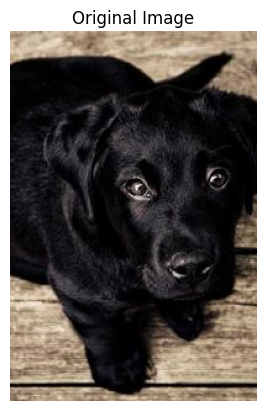

In [ ]:
import matplotlib.pyplot as plt
from skimage import io, color
import numpy as np



image_url = 'https://picsum.photos/id/237/200/300' # A reliable placeholder image service

# Load the image
try:
    image = io.imread(image_url)
    print(f"Image loaded successfully with shape: {image.shape}")
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image: {e}")
    image = None

### 2. Convert to Grayscale (Pixel Intensity)

To focus on pixel intensity, we'll convert the image to grayscale. A grayscale image has a single channel where each pixel value directly represents its intensity (from black to white).

Grayscale image shape: (300, 200)


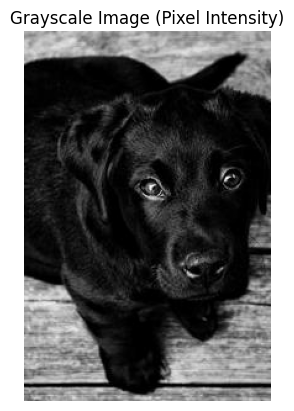

In [ ]:
if image is not None:
    
    if image.ndim == 3 or (image.ndim == 4 and image.shape[-1] > 1):
        gray_image = color.rgb2gray(image)
    else:
        gray_image = image 

    print(f"Grayscale image shape: {gray_image.shape}")
    plt.imshow(gray_image, cmap='gray')
    plt.title("Grayscale Image (Pixel Intensity)")
    plt.axis('off')
    plt.show()
else:
    print("Cannot process: Image was not loaded.")

### 3. Extract Features from Pixel Intensity

Now, we'll extract some simple features from the grayscale image's pixel intensities:
*   **Mean Intensity**: The average pixel value.
*   **Standard Deviation**: The spread of pixel values.
*   **Intensity Histogram**: A distribution of pixel intensities, which can be a powerful feature vector itself. We'll compute 256 bins for the 0-255 intensity range (after scaling to 0-1 for floating point images).

These features can be used for tasks like image classification, content-based image retrieval, or basic image analysis.

Mean Pixel Intensity: 0.2341
Standard Deviation of Pixel Intensity: 0.2610

Intensity Histogram (first 10 bins): [4029 2173 2142 1983 1732 1531 1414 1262 1208 1086]
Total pixels in histogram: 60000 (should match image size)


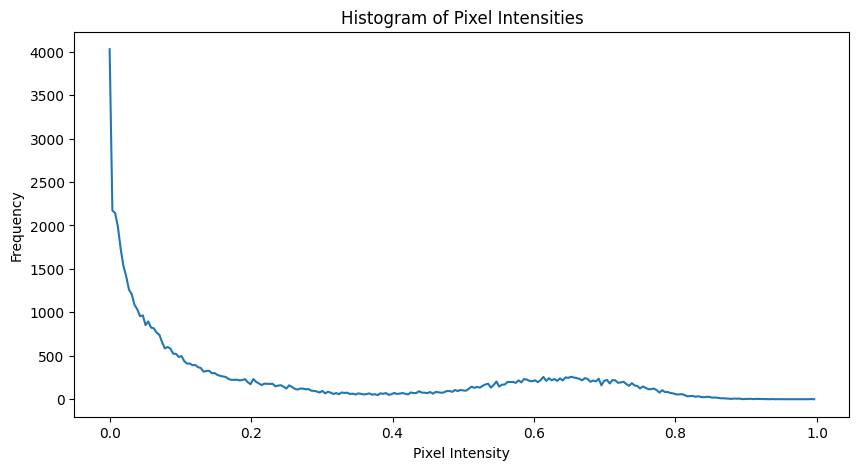


Normalized Histogram (sum should be close to 1): 1.0000

The normalized histogram itself can serve as a feature vector.


In [ ]:
if 'gray_image' in locals() and gray_image is not None:
    pixel_intensities = gray_image.flatten()


    mean_intensity = np.mean(pixel_intensities)
    print(f"Mean Pixel Intensity: {mean_intensity:.4f}")

    std_intensity = np.std(pixel_intensities)
    print(f"Standard Deviation of Pixel Intensity: {std_intensity:.4f}")

    hist, bins = np.histogram(pixel_intensities, bins=256, range=(0.0, 1.0))

    print(f"\nIntensity Histogram (first 10 bins): {hist[:10]}")
    print(f"Total pixels in histogram: {np.sum(hist)} (should match image size)")

    # Plot the histogram
    plt.figure(figsize=(10, 5))
    plt.title("Histogram of Pixel Intensities")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.plot(bins[:-1], hist)
    plt.show()

    normalized_hist = hist / np.sum(hist)
    print(f"\nNormalized Histogram (sum should be close to 1): {np.sum(normalized_hist):.4f}")
    print("\nThe normalized histogram itself can serve as a feature vector.")

else:
    print("Cannot extract features: Grayscale image was not created.")

### 4. Representing as an 8x8 Vector

To represent the image as an 8x8 vector, we'll resize the grayscale image to an 8x8 pixel resolution. This is a common technique for dimensionality reduction or preparing images for certain machine learning models (e.g., for digits classification where features are often flattened 8x8 arrays).

Each element in the resulting 8x8 array will correspond to the intensity of a pixel in that downsampled grid.

Resized 8x8 image shape: (8, 8)


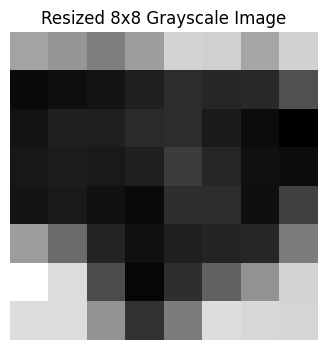


Numerical 8x8 Pixel Vector:
[[0.4254 0.3942 0.336  0.4103 0.5427 0.5344 0.4323 0.5361]
 [0.0539 0.0649 0.0787 0.1047 0.1384 0.1222 0.1276 0.2245]
 [0.0756 0.1057 0.1068 0.1329 0.1389 0.0953 0.059  0.0297]
 [0.0854 0.0985 0.091  0.1053 0.1755 0.1219 0.0701 0.0626]
 [0.0784 0.0913 0.0727 0.0561 0.1422 0.1392 0.0676 0.1849]
 [0.4104 0.2901 0.1169 0.0691 0.1093 0.1186 0.1226 0.331 ]
 [0.6497 0.5637 0.2127 0.0464 0.1412 0.2667 0.3837 0.5447]
 [0.5666 0.5672 0.3899 0.1523 0.3319 0.5666 0.5535 0.5473]]


In [33]:
from skimage.transform import resize

if 'gray_image' in locals() and gray_image is not None:
    # Resize the grayscale image to 8x8 pixels
    image_8x8 = resize(gray_image, (8, 8), anti_aliasing=True)

    print(f"Resized 8x8 image shape: {image_8x8.shape}")

    # Display the 8x8 image
    plt.figure(figsize=(4, 4))
    plt.imshow(image_8x8, cmap='gray')
    plt.title("Resized 8x8 Grayscale Image")
    plt.axis('off')
    plt.show()

    print("\nNumerical 8x8 Pixel Vector:")
    # Display the numerical values (vector representation)
    # Using numpy to print with controlled precision
    np.set_printoptions(precision=4, suppress=True)
    print(image_8x8)

    # You can also flatten this 8x8 array into a 1D vector of 64 elements if needed
    # flattened_vector = image_8x8.flatten()
    # print(f"\nFlattened 1D vector (length {len(flattened_vector)}):")
    # print(flattened_vector)

else:
    print("Cannot create 8x8 representation: Grayscale image was not created or is missing.")